## Song Recommender System Documentation
This notebook outlines the process of building a song recommender system. The key steps include data preprocessing, feature encoding, standardization, visualization, and feature selection.


## Libraries used

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import plotly.express as px 
from sklearn.preprocessing import StandardScaler

In [4]:
original_df= pd.read_csv(r'C:\Users\Mohamed Amr\Desktop\Sumerge AI internship\Song Recommender System\Dataset Excel\Songs_Recommender_System.csv')
df=original_df.copy()



# Data Preprocessing 
    


## 1. Loading the Dataset
We begin by loading the dataset and displaying its first few rows to understand its structure and contents.
    


## 2. Checking for Duplicates and Missing Values
Before proceeding with feature engineering, we need to ensure the dataset is clean. We check for any duplicate rows and missing values.


We found no duplicate rows and no missing values in the dataset. 
The columns `id`, `release_date`, and `name` were dropped as they are not relevant to the recommendation system.


# Encoding

The `artists` column was encoded using frequency encoding. This method assigns a numerical value to each artist based on their frequency of occurrence in the dataset.


In [5]:
artist_freq = df['artists'].value_counts() / len(df)
df['artists_encoded'] = df['artists'].map(artist_freq)

# Standardization

We applied `StandardScaler` to standardize the numerical features, which ensures that each feature contributes equally to the model.


In [6]:
features_to_standardize = [ 'key', 'popularity', 'tempo','loudness']
scaler = StandardScaler()
df[features_to_standardize] = scaler.fit_transform(df[features_to_standardize])

# Visualizig data



To understand the data better, we plotted the features using line plots. This visualization helps identify patterns and trends in the data.


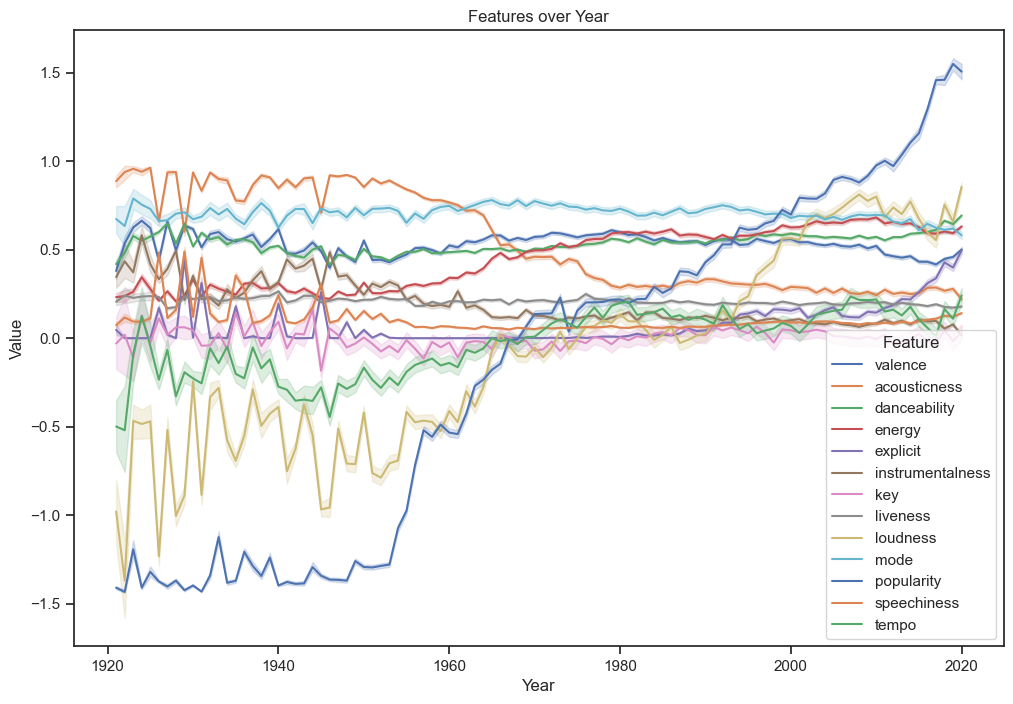

# Feature Selection 

We apply a variance threshold to further reduce the number of features by removing those with low variance. Features with low variance do not contribute much to the predictive power of the model.
    

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.select_dtypes(include=[np.number]))

var_thresh = VarianceThreshold(threshold=0.1)
X_var_thresh = var_thresh.fit_transform(X_scaled)

selected_indices_var_thresh = var_thresh.get_support(indices=True)
selected_features_var_thresh = df.columns[selected_indices_var_thresh]
print(f"Selected features: {list(selected_features_var_thresh)}")
    


### Correlation Matrix
Next, we compute the correlation matrix of the dataset to identify relationships between features. Highly correlated features may contain redundant information.
    

To reduce redundancy, we drop one feature from each pair of features with a correlation coefficient greater than 0.7.

In [ ]:
correlation_matrix = df.corr().abs()
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]
df = df.drop(columns=to_drop)
reduced_correlation_matrix = df.corr().abs()

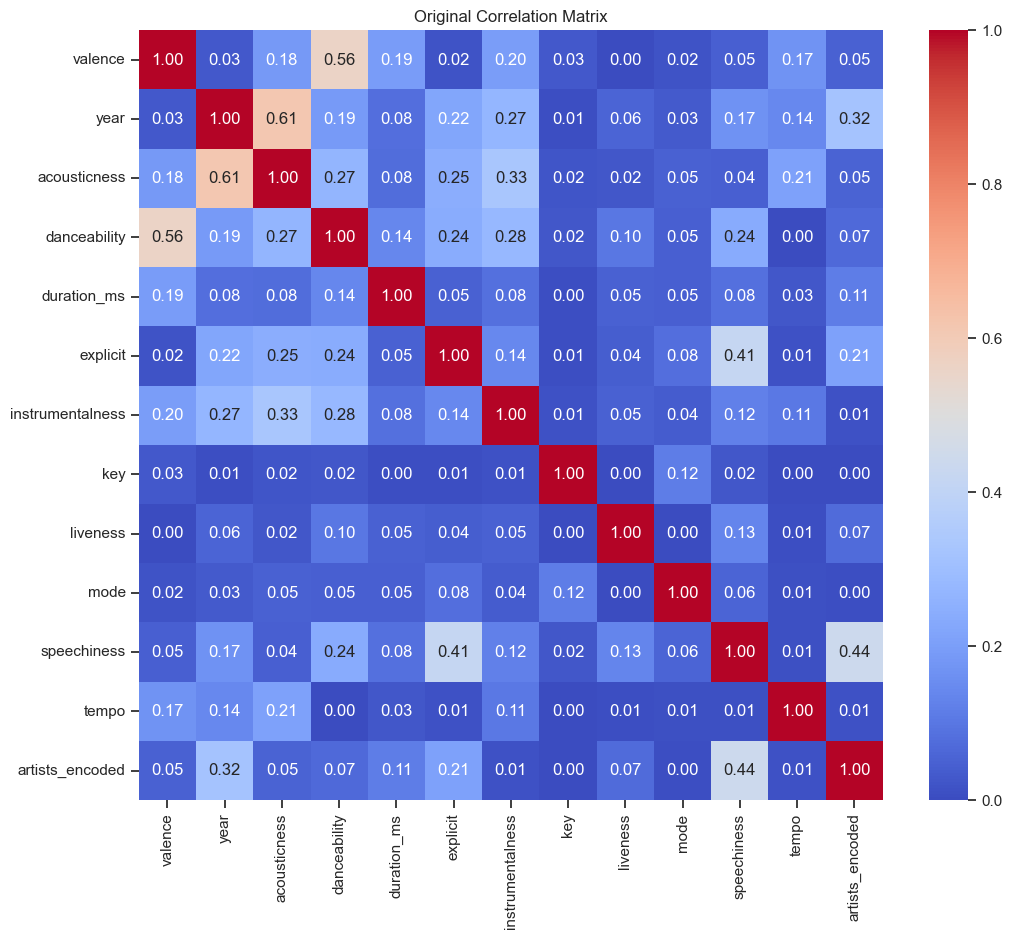

* After applying correlation reduction and standardization, we have selected the most relevant features for building the song recommender model.
* We've also applied Variance threshold to select the important features, which removes features wiht variance less than the specified threshold(0.1) 


### A problem we faced

We wanted to cluster the data into genres,so it would be easier to select based on the similarity betweem them, we used K-means for clustering and tried 2 algorithms for visualization (t-SNE,PCA), t-SNE was more effective but it was way slower than PCA.




## Recommender System

### Continuation of the problems we faced

* So when we tried clustering, we applied cosine similarity for each genre.

* After alot of thought and consideration, We decided that it was better to just use cosine similarity on the features in the dataset directly and not use clustering, because clustering doesnt really serve the purpose of our Case, the Recommender System shouldn't really recommend based on just genres *but* it should consider other features like " acousticness "," tempo "and " danceabiltiy " 




*  Then we've built a recommender system method that takes the song name, genre and no. of recommendations(n) as arguments and then it ouputs n recommendations.
 


* The recommend_songs function recommends similar songs based on cosine similarity of their features. It requires the song name (song_name), a DataFrame with numerical features (df), the original DataFrame containing song names and details (original_df), and optionally the number of recommendations (num_recommendations). The function verifies the presence of necessary columns, calculates similarity scores, and returns a DataFrame with the names and artists of the most similar songs. It also handles cases where the song or indices are not found, raising appropriate errors.

## To wrap it up

In this project, we successfully developed and implemented a machine learning-based recommender system that efficiently categorizes and suggests items based on user preferences. By leveraging cosine similarity, we were able to provide accurate and personalized recommendations that enhance user experience. This model not only meets the initial project goals but also demonstrates the potential for further expansion and integration into real-world applications.

Looking ahead, the flexibility of our model allows for continuous improvement and adaptation to evolving user needs. We believe that with ongoing refinement, this recommender system can play a significant role in various industries, driving engagement and satisfaction. This project underscores the power of machine learning in transforming data into actionable insights, paving the way for future innovations.

## Future Services and Enhancements

While our recommender system has demonstrated strong performance, there are several areas where we can extend its capabilities:

### 1. *Enhanced Personalization*
   - *User Behavior Tracking:* Implementing real-time tracking of user interactions to continuously update recommendations based on the latest user activity.
   - *Collaborative Filtering Integration:* Combining content-based recommendations with collaborative filtering to further improve accuracy by considering user similarities.

### 2. *Scalability*
   - *Cloud Deployment:* Scaling the system to handle larger datasets and user bases by deploying on cloud platforms, ensuring fast and reliable service.

### 3. *Cross-Platform Integration*
   - *Mobile Application Support:* Extending the recommender system to mobile platforms, allowing users to receive personalized recommendations on-the-go.
   - *API Development:* Creating robust APIs to integrate the recommendation engine with various platforms, enabling seamless integration with existing systems.


These enhancements can significantly extend the utility and effectiveness of our recommender system, ensuring it remains a valuable tool in an ever-evolving digital landscape.